# LSTM — OG Data + Hyperparameter Optimisation

Combines the full data preprocessing from `LSTM_dave_adaption1` with the hyperparameter
search, CV structure, and evaluation from `LSTM_dave_hyperparaopt`.

## Structure
| Section | Source | Description |
|---|---|---|
| Imports | hyperparaopt | Libraries incl. StandardScaler |
| Load data | adaption1 | Raw preprocessed_data.csv |
| Window config | hyperparaopt | DATE_START / DATE_END / CV_FOLDS |
| Naive baseline | adaption1 | shift(24) on target |
| Full preprocessing | adaption1 | Weather shift, rolling features, wind dir cyclical, time cyclical, is_weekend |
| Define X / y | hyperparaopt | Feature matrix + target |
| Train/test split | hyperparaopt | 80/20 time-ordered |
| Sequence config | hyperparaopt | INPUT_LENGTH=336, STRIDE=24 |
| Sequence builder | hyperparaopt | Sliding-window helper |
| Model builder | hyperparaopt | MAE loss, params dict |
| Random search | hyperparaopt | 3 folds × 3 months |
| 12-fold CV | hyperparaopt | Monthly folds, naive comparison |
| Summary + plots | hyperparaopt | MAE / RMSE / MASE + best/worst week |
| Final model + save | hyperparaopt | Train on 80%, save with descriptive name |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

import optuna
from optuna.visualization import matplotlib as optuna_mpl

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from keras import models, Input, layers, optimizers
from keras.callbacks import EarlyStopping
from numpy.lib.stride_tricks import sliding_window_view

import sys
sys.path.append('../../Data_Processing')
from full_cleaning_preprocessing_script import run_full_preprocessing

## Load Data

In [3]:
df = run_full_preprocessing(
    data_folder = '/home/jpelletier/Downloads/data',
    start_date  = '2014-01-01',
    end_date    = '2024-12-31',
)
df['datetime_utc12'] = pd.to_datetime(df['datetime_utc12'])
df.set_index('datetime_utc12', inplace=True)

TARGET = 'el_price_dol_MWh_OTA2201'

print(df.shape)
print(df.columns.tolist())
df.head()

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2014-01-01  →  2024-12-31
  save_path   : None

[1/9] Wholesale price...
      Anchor df shape: (96408, 10)

[2/9] Generation output...
      Shape after merge: (96408, 19)

[3/9] Wind...
      Shape after merge: (96408, 29)

[4/9] Solar...
      Shape after merge: (96408, 41)

[5/9] Temperature...
      Shape after merge: (96408, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_Storage_LakeTekapo.csv  (prefix: 'SI_TKA_')
      M

,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,Coal,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
datetime_utc12,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,33.755,34.900,34.265,34.720,NaN,37.845,36.420,36.195,36.865,0.0,...,0.868,0.426,373.0,386.0,1.0,0.0,50.2,250.0,0.0,0.0
2014-01-01 01:00:00,32.455,33.555,32.945,33.385,NaN,36.350,35.000,34.785,35.425,0.0,...,0.818,0.375,366.0,367.0,1.0,0.0,50.2,250.0,0.0,0.0
2014-01-01 02:00:00,5.555,5.745,5.635,5.710,NaN,6.215,5.975,5.950,6.050,0.0,...,0.778,0.347,326.0,328.0,1.0,0.0,50.2,250.0,0.0,0.0
2014-01-01 03:00:00,3.865,3.990,3.920,3.970,NaN,4.315,4.150,4.135,4.210,0.0,...,0.762,0.338,293.5,319.0,1.0,0.0,50.2,250.0,0.0,0.0
2014-01-01 04:00:00,2.525,2.605,2.565,2.595,NaN,2.815,2.695,2.700,2.745,0.0,...,0.764,0.351,288.0,314.0,1.0,0.0,50.2,250.0,0.0,0.0


## Window Configuration

Set `DATE_START` / `DATE_END` to run on a shorter slice (e.g. for a fast optimisation trial).
Set both to `None` to use the full dataset.

Reduce `CV_FOLDS` when the window is short — rule of thumb: `CV_FOLDS × 720 ≤ 60% of total rows`.

In [4]:
DATE_START = None   # e.g. '2022-01-01' — None = use full dataset
DATE_END   = None   # e.g. '2024-12-31' — None = use full dataset
CV_FOLDS   = 12     # reduce to 6 for short windows (rule: CV_FOLDS × 720 ≤ 60% of rows)

# Fixed validation windows for the hyperparameter search
# Each tuple = (start, end) of a validation period — must fall inside the 80% train split
# Chosen to cover NZ summer / autumn / winter of 2022
SEARCH_WINDOWS = [
    ('2022-01-01', '2022-04-01'),   # NZ summer  (3 months)
    ('2022-04-01', '2022-07-01'),   # NZ autumn  (3 months)
    ('2022-07-01', '2022-10-01'),   # NZ winter  (3 months)
]

if DATE_START:
    df = df[df.index >= DATE_START]
if DATE_END:
    df = df[df.index <= DATE_END]

print(f"Active window : {df.index.min().date()} → {df.index.max().date()}")
print(f"Rows          : {len(df)}")
print(f"CV folds      : {CV_FOLDS}  (test_size=720 each → {CV_FOLDS * 720} rows used as test)")
print(f"Search windows: {len(SEARCH_WINDOWS)} × 3-month fixed folds (NZ summer / autumn / winter 2022)")

Active window : 2014-01-01 → 2024-12-31
Rows          : 96408
CV folds      : 12  (test_size=720 each → 8640 rows used as test)
Search windows: 3 × 3-month fixed folds (NZ summer / autumn / winter 2022)


## Naive Baseline

Computed before preprocessing so the shift is based on the raw target.
"Tomorrow looks like today same hour" = shift(24).
Kept as a separate Series — never enters the feature matrix.

In [5]:
naive_baseline = df[TARGET].shift(24).rename('naive_baseline')

mask = naive_baseline.notna()
mae_naive  = mean_absolute_error(df.loc[mask, TARGET], naive_baseline[mask])
rmse_naive = np.sqrt(mean_squared_error(df.loc[mask, TARGET], naive_baseline[mask]))
print(f'Naive (shift-24) MAE  : {mae_naive:.4f}')
print(f'Naive (shift-24) RMSE : {rmse_naive:.4f}')

Naive (shift-24) MAE  : 34.4126
Naive (shift-24) RMSE : 88.8193


## Full Preprocessing

Carried over from `LSTM_dave_adaption1` with the addition of `is_weekend`.

Steps:
1. Sort chronologically
2. Weather shift(-24) — pulls tomorrow's weather into today's row (simulates forecast availability)
3. ffill + bfill — covers missing values and the trailing NaNs from the weather shift
4. Cyclical time features — hour, day-of-year, day-of-week (sin/cos)
5. `is_weekend` binary flag
6. Rolling price features — 24h mean of target and all-node average
7. Wind direction cyclical encoding — replaces degree columns with sin/cos

In [6]:
# 1. Sort
df = df.sort_index()

In [7]:
# 2. Weather shift(-24) + ffill/bfill
#
# When predicting Saturday prices, we have Saturday's weather forecast.
# shift(-24) pulls Saturday's weather into Friday's rows so the LSTM input
# window (which ends on Friday) can see it.
# The last 24 rows lose their weather values (nothing below to pull) → bfill mops up.

weather_cols = [
    'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg',
    'wellington_wind_kmh', 'wellington_wind_dir_deg',
    'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg',
    'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg',
    'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg',
    'auckland_shortwave_wm2', 'auckland_sunshine_s',
    'christchurch_shortwave_wm2', 'christchurch_sunshine_s',
    'wellington_shortwave_wm2', 'wellington_sunshine_s',
    'hamilton_shortwave_wm2', 'hamilton_sunshine_s',
    'tauranga_shortwave_wm2', 'tauranga_sunshine_s',
    'dunedin_shortwave_wm2', 'dunedin_sunshine_s',
    'auckland_temp_c', 'christchurch_temp_c', 'wellington_temp_c',
    'hamilton_temp_c', 'tauranga_temp_c', 'dunedin_temp_c',
]
df[weather_cols] = df[weather_cols].shift(-24)
df = df.ffill().bfill()

In [8]:
# 3 & 4. Cyclical time features + is_weekend
hour = df.index.hour
doy  = df.index.dayofyear
dow  = df.index.dayofweek

df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['doy_sin']  = np.sin(2 * np.pi * doy  / 365)
df['doy_cos']  = np.cos(2 * np.pi * doy  / 365)
df['dow_sin']  = np.sin(2 * np.pi * dow  / 7)
df['dow_cos']  = np.cos(2 * np.pi * dow  / 7)

# is_weekend — binary flag, no cyclical encoding needed
df['is_weekend'] = pd.Series(dow, index=df.index).isin([5, 6]).astype(int)

In [9]:
# 5. Rolling price features (backward-only → no leakage)
price_cols = [
    'el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201',
    'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201',
    'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201',
    'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201',
    'el_price_dol_MWh_WKM2201',
]
df['target_roll24']    = df[TARGET].rolling(window=24, min_periods=1).mean()
df['all_price_mean']   = df[price_cols].mean(axis=1)
df['all_price_roll24'] = df['all_price_mean'].rolling(window=24, min_periods=1).mean()
df = df.drop(columns='all_price_mean')

In [10]:
# 6. Wind direction cyclical encoding (degrees are circular: 359° ≈ 1°)
wind_dir_cols = [
    'palmerston_north_wind_dir_deg', 'wellington_wind_dir_deg',
    'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_dir_deg',
    'kaiwera_downs_southland_wind_dir_deg',
]
for col in wind_dir_cols:
    rad  = np.deg2rad(df[col])
    base = col.replace('_deg', '')
    df[f'{base}_sin'] = np.sin(rad)
    df[f'{base}_cos'] = np.cos(rad)
df = df.drop(columns=wind_dir_cols)

print(f'Final shape : {df.shape}')
print(f'Date range  : {df.index.min().date()} → {df.index.max().date()}')

Final shape : (96408, 94)
Date range  : 2014-01-01 → 2024-12-31


## Define X and y

In [11]:
exclude_cols = [TARGET]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_df = df[feature_cols]
y_s  = df[TARGET]

# Reset to integer index for downstream slicing
X_df = X_df.reset_index(drop=True)
y_s  = y_s.reset_index(drop=True)
naive_baseline = naive_baseline.reset_index(drop=True)
timestamps = df.index  # keep datetime index separately for labels

print('Feature matrix shape:', X_df.shape)
print('Number of features:  ', len(feature_cols))

Feature matrix shape: (96408, 93)
Number of features:   93


## Train / Test Split — 80 / 20 time-ordered

In [12]:
split_index = int(len(X_df) * 0.8)

X_train_df = X_df.iloc[:split_index]
X_test_df  = X_df.iloc[split_index:]
y_train_s  = y_s.iloc[:split_index]
y_test_s   = y_s.iloc[split_index:]

print(f"Train: {X_train_df.shape}  {timestamps[0].date()} → {timestamps[split_index-1].date()}")
print(f"Test : {X_test_df.shape}   {timestamps[split_index].date()} → {timestamps[-1].date()}")

Train: (77126, 93)  2014-01-01 → 2022-10-19
Test : (19282, 93)   2022-10-19 → 2024-12-31


## Sequence Configuration

In [13]:
INPUT_LENGTH  = 168   # 2 weeks of hourly history as input window
OUTPUT_LENGTH = 24    # predict the next 24 hours
HORIZON       = 1     # gap between last input row and first predicted row
STRIDE        = 24    # step between consecutive sequences (1 day)

## Sequence Builder

In [14]:
def build_sequences(X_arr, y_arr, input_length, output_length, horizon, stride, shuffle=False):
    """Return (X_seq, y_seq) sliding windows from pre-scaled arrays."""
    n = len(X_arr)
    last_start = n - input_length - horizon - output_length + 2
    starts = np.arange(0, last_start, stride)

    X_win = sliding_window_view(X_arr, input_length, axis=0)
    X_seq = X_win[starts].transpose(0, 2, 1).astype(np.float32)

    y_win = sliding_window_view(y_arr, output_length)
    y_seq = y_win[starts + input_length + horizon - 1].astype(np.float32)

    if shuffle:
        idx = np.random.permutation(len(X_seq))
        X_seq, y_seq = X_seq[idx], y_seq[idx]

    return X_seq, y_seq

## Model Builder

In [15]:
def build_model(n_features, params):
    model = models.Sequential([
        Input(shape=(INPUT_LENGTH, n_features)),
        layers.LSTM(params['lstm1_units'],
                    activation='tanh',
                    return_sequences=True,
                    dropout=params['dropout']),
        layers.LSTM(params['lstm2_units'],
                    activation='tanh',
                    return_sequences=False,
                    dropout=params['dropout']),
        layers.Dense(params['dense_units'], activation='relu'),
        layers.Dropout(params['dropout']),
        layers.Dense(OUTPUT_LENGTH, activation='linear'),
    ])
    model.compile(
        loss='huber',
        optimizer=optimizers.Adam(learning_rate=params['learning_rate']),
        metrics=['mae'],
    )
    return model

## Random Search — Hyperparameter Optimisation

Searches `N_ITER` random combinations on the **training set only**.
Inner CV: 3 folds × 3-month validation windows — covers ~3 seasons of the most recent training year.

| Parameter | Options | Notes |
|---|---|---|
| `lstm1_units` | 32, 64, 128, 256 | Capacity of first recurrent layer |
| `lstm2_units` | 16, 32, 64 | Capacity of second recurrent layer |
| `dropout` | 0.1, 0.2, 0.3, 0.4 | Regularisation strength |
| `dense_units` | 16, 32, 64 | Head capacity before output |
| `learning_rate` | 0.001, 0.005, 0.01 | Adam step size |
| `batch_size` | 16, 32, 64 | Sequences per gradient update |

In [16]:
N_TRIALS = 20   # Optuna trials — fewer needed than random search due to TPE learning

# ── Build search folds from fixed SEARCH_WINDOWS ──────────────────────────
# df has datetime index — use it directly to map date windows to row indices.
# Training for each fold = all rows BEFORE the window start (expanding window).

train_ts = pd.Series(timestamps[:split_index])

search_folds = []
for start_date, end_date in SEARCH_WINDOWS:
    val_mask = (train_ts >= start_date) & (train_ts < end_date)
    tr_mask  = train_ts < start_date
    tr_idx   = np.where(tr_mask.values)[0]
    val_idx  = np.where(val_mask.values)[0]
    if len(tr_idx) > INPUT_LENGTH and len(val_idx) > INPUT_LENGTH + OUTPUT_LENGTH:
        search_folds.append((tr_idx, val_idx))
    else:
        print(f"  ⚠ Window {start_date}→{end_date} skipped — insufficient rows")

print(f"Search folds built: {len(search_folds)}")
for i, (tr, va) in enumerate(search_folds):
    print(f"  Fold {i+1}: train {len(tr)} rows  |  "
          f"val {train_ts.iloc[va[0]].date()} → {train_ts.iloc[va[-1]].date()}  ({len(va)} rows)")

X_train_arr = X_train_df.values
y_train_arr = y_train_s.values
n_features  = X_train_arr.shape[1]

# ── Optuna objective function ──────────────────────────────────────────────
def objective(trial):
    params = {
        'lstm1_units':   trial.suggest_categorical('lstm1_units',   [32, 64, 128, 256]),
        'lstm2_units':   trial.suggest_categorical('lstm2_units',   [16, 32, 64]),
        'dropout':       trial.suggest_categorical('dropout',       [0.1, 0.2, 0.3, 0.4]),
        'dense_units':   trial.suggest_categorical('dense_units',   [16, 32, 64]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.001, 0.005, 0.01]),
        'batch_size':    trial.suggest_categorical('batch_size',    [16, 32, 64]),
    }

    fold_maes = []
    for fold_i, (tr_idx, val_idx) in enumerate(search_folds):
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_train_arr[tr_idx])
        X_val_sc = scaler.transform(X_train_arr[val_idx])
        y_tr     = y_train_arr[tr_idx]
        y_val    = y_train_arr[val_idx]

        X_tr_seq,  y_tr_seq  = build_sequences(X_tr_sc,  y_tr,  INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=True)
        X_val_seq, y_val_seq = build_sequences(X_val_sc, y_val, INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=False)

        if len(X_tr_seq) == 0 or len(X_val_seq) == 0:
            continue

        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model = build_model(n_features, params)
        model.fit(
            X_tr_seq, y_tr_seq,
            validation_data=(X_val_seq, y_val_seq),
            batch_size=params['batch_size'],
            epochs=100,
            callbacks=[es],
            verbose=0,
        )

        y_val_pred = model.predict(X_val_seq, verbose=0).flatten()
        fold_mae   = mean_absolute_error(y_val_seq.flatten(), y_val_pred)
        fold_maes.append(fold_mae)

        # Report running mean to Optuna — allows pruning after each fold
        trial.report(float(np.mean(fold_maes)), step=fold_i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_maes)) if fold_maes else float('inf')

# ── Run study ──────────────────────────────────────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

BEST_PARAMS = study.best_params

print(f"\nBest trial    : #{study.best_trial.number}")
print(f"Best CV MAE   : {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in sorted(BEST_PARAMS.items()):
    print(f"  {k:<18}: {v}")

Search folds built: 3
  Fold 1: train 70127 rows  |  val 2022-01-01 → 2022-03-31  (2160 rows)
  Fold 2: train 72287 rows  |  val 2022-04-01 → 2022-06-30  (2184 rows)
  Fold 3: train 74471 rows  |  val 2022-07-01 → 2022-09-30  (2208 rows)


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 12. Best value: 42.0944: 100%|██████████| 20/20 [11:29:49<00:00, 2069.48s/it]  


Best trial    : #12
Best CV MAE   : 42.0944

Best parameters:
  batch_size        : 64
  dense_units       : 16
  dropout           : 0.2
  learning_rate     : 0.001
  lstm1_units       : 64
  lstm2_units       : 64


## Optuna Search Visualisation

/tmp/ipykernel_121727/395492974.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna_mpl.plot_optimization_history(study)


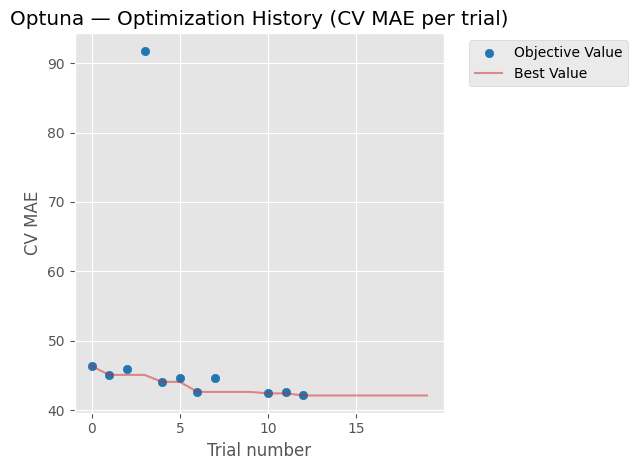

/tmp/ipykernel_121727/395492974.py:10: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna_mpl.plot_param_importances(study)


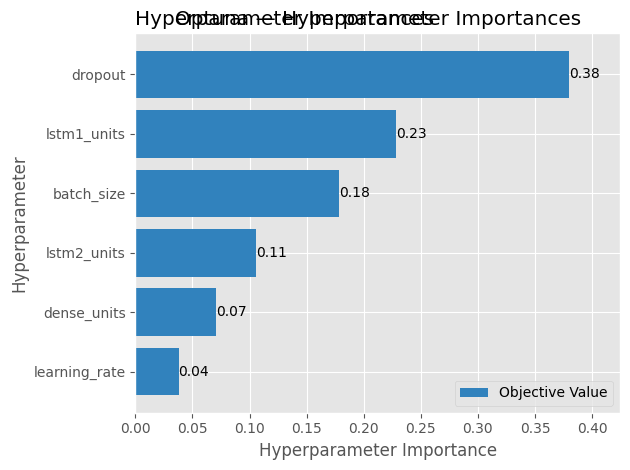

 trial     cv_mae    state  params_batch_size  params_dense_units  params_dropout  params_learning_rate  params_lstm1_units  params_lstm2_units
    12  42.094368 COMPLETE                 64                  16             0.2                 0.001                  64                  64
    10  42.400411 COMPLETE                 64                  16             0.2                 0.001                  64                  64
     6  42.607563 COMPLETE                 64                  64             0.1                 0.001                  64                  64
    11  42.607915 COMPLETE                 64                  16             0.2                 0.001                  64                  64
    19  43.238245   PRUNED                 64                  16             0.2                 0.005                  64                  16
    13  43.253592   PRUNED                 64                  16             0.2                 0.001                  64             

In [17]:
# ── Optimization history — MAE per trial, best so far highlighted ──────────
ax = optuna_mpl.plot_optimization_history(study)
ax.set_title('Optuna — Optimization History (CV MAE per trial)')
ax.set_xlabel('Trial number')
ax.set_ylabel('CV MAE')
plt.tight_layout()
plt.show()

# ── Parameter importances — which hyperparameters mattered most ────────────
ax = optuna_mpl.plot_param_importances(study)
ax.set_title('Optuna — Hyperparameter Importances')
plt.tight_layout()
plt.show()

# ── Trial summary table ────────────────────────────────────────────────────
trials_df = study.trials_dataframe().sort_values('value')
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
print(trials_df[['number', 'value', 'state'] + param_cols]
      .rename(columns={'number': 'trial', 'value': 'cv_mae'})
      .to_string(index=False))

## 12-Fold Time-Series CV

Uses best params from the random search.
`test_size=720` ≈ 1 month. Number of folds controlled by `CV_FOLDS` in the Window Configuration cell.
Naive baseline looked up from the pre-computed `naive_baseline` Series (shift-24 on target).

In [18]:
X_arr  = X_df.values
y_arr  = y_s.values
ts_arr = timestamps  # datetime index for month labels

tscv  = TimeSeriesSplit(n_splits=CV_FOLDS, test_size=720)
es_cv = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

fold_results = []

print(f"{'Fold':>4}  {'Month':>10}  {'MAE model':>10}  {'MAE naive':>10}  "
      f"{'RMSE model':>11}  {'RMSE naive':>11}  {'MASE':>6}")
print('-' * 72)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_arr), start=1):

    # Scale
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_arr[train_idx])
    X_te_sc  = scaler.transform(X_arr[test_idx])
    y_tr     = y_arr[train_idx]
    y_te_raw = y_arr[test_idx]

    # Build sequences
    X_tr_seq, y_tr_seq = build_sequences(X_tr_sc, y_tr, INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=True)

    lookback_X = X_tr_sc[-INPUT_LENGTH:]
    lookback_y = y_tr[-INPUT_LENGTH:]
    X_te_full  = np.concatenate([lookback_X, X_te_sc])
    y_te_full  = np.concatenate([lookback_y, y_te_raw])
    X_te_seq, y_te_seq = build_sequences(X_te_full, y_te_full, INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=False)

    # Train
    model = build_model(n_features, BEST_PARAMS)
    model.fit(
        X_tr_seq, y_tr_seq,
        validation_split=0.15,
        shuffle=False,
        batch_size=BEST_PARAMS['batch_size'],
        epochs=100,
        callbacks=[es_cv],
        verbose=0,
    )

    y_model  = np.clip(model.predict(X_te_seq, verbose=0).flatten(), 0, None)
    y_actual = y_te_seq.flatten()

    # Naive baseline — look up shift-24 values by position
    seq_starts  = np.arange(0, len(X_te_seq)) * STRIDE
    pred_starts = seq_starts + INPUT_LENGTH + HORIZON - 1
    naive_seqs  = np.array([
        naive_baseline.iloc[test_idx[0] + ps : test_idx[0] + ps + OUTPUT_LENGTH].values
        if test_idx[0] + ps + OUTPUT_LENGTH <= len(naive_baseline) else np.full(OUTPUT_LENGTH, np.nan)
        for ps in pred_starts
    ])
    y_naive    = naive_seqs.flatten()
    valid_mask = ~np.isnan(y_naive)
    mae_n  = mean_absolute_error(y_actual[valid_mask], y_naive[valid_mask])
    rmse_n = np.sqrt(mean_squared_error(y_actual[valid_mask], y_naive[valid_mask]))

    mae_m  = mean_absolute_error(y_actual, y_model)
    rmse_m = np.sqrt(mean_squared_error(y_actual, y_model))
    mase   = mae_m / mae_n if mae_n > 0 else np.nan

    month_label = pd.Timestamp(ts_arr[test_idx[0]]).strftime('%b %Y')

    fold_results.append({
        'fold':       fold,
        'month':      month_label,
        'y_actual':   y_actual,
        'y_model':    y_model,
        'y_naive':    y_naive,
        'mae_model':  mae_m,
        'mae_naive':  mae_n,
        'rmse_model': rmse_m,
        'rmse_naive': rmse_n,
        'mase':       mase,
    })

    print(f"{fold:>4}  {month_label:>10}  {mae_m:>10.2f}  {mae_n:>10.2f}  "
          f"{rmse_m:>11.2f}  {rmse_n:>11.2f}  {mase:>6.3f}")

Fold       Month   MAE model   MAE naive   RMSE model   RMSE naive    MASE
------------------------------------------------------------------------
   1    Jan 2024       56.30      102.29        84.38       136.57   0.550
   2    Feb 2024      174.81       75.36       197.50       107.91   2.320
   3    Mar 2024      227.34       46.89       234.61        63.93   4.848
   4    Apr 2024      221.33       82.76       230.77       257.24   2.674
   5    May 2024      294.66       86.04       395.32       229.08   3.425
   6    Jun 2024      262.03       52.70       266.22        85.72   4.972
   7    Jul 2024      372.54      139.43       389.14       213.66   2.672
   8    Aug 2024      429.60      186.26       516.13       240.95   2.306
   9    Sep 2024       79.04       80.71       138.90       150.07   0.979
  10    Oct 2024       54.15       61.75        76.12        77.70   0.877
  11    Nov 2024       31.08       39.58        52.51        56.65   0.785
  12    Dec 2024       33.5

## Summary Table

In [19]:
summary = pd.DataFrame([{
    'Month':       r['month'],
    'MAE model':   r['mae_model'],
    'MAE naive':   r['mae_naive'],
    'RMSE model':  r['rmse_model'],
    'RMSE naive':  r['rmse_naive'],
    'MASE':        r['mase'],
    'Beats naive': '✓' if r['mase'] < 1 else '✗'
} for r in fold_results])

avg_row = pd.DataFrame([{
    'Month':       'AVERAGE',
    'MAE model':   summary['MAE model'].mean(),
    'MAE naive':   summary['MAE naive'].mean(),
    'RMSE model':  summary['RMSE model'].mean(),
    'RMSE naive':  summary['RMSE naive'].mean(),
    'MASE':        summary['MASE'].mean(),
    'Beats naive': f"{(summary['MASE'] < 1).sum()} / {CV_FOLDS}"
}])

pd.set_option('display.float_format', '{:.2f}'.format)
print(pd.concat([summary, avg_row], ignore_index=True).to_string(index=False))

   Month  MAE model  MAE naive  RMSE model  RMSE naive  MASE Beats naive
Jan 2024      56.30     102.29       84.38      136.57  0.55           ✓
Feb 2024     174.81      75.36      197.50      107.91  2.32           ✗
Mar 2024     227.34      46.89      234.61       63.93  4.85           ✗
Apr 2024     221.33      82.76      230.77      257.24  2.67           ✗
May 2024     294.66      86.04      395.32      229.08  3.42           ✗
Jun 2024     262.03      52.70      266.22       85.72  4.97           ✗
Jul 2024     372.54     139.43      389.14      213.66  2.67           ✗
Aug 2024     429.60     186.26      516.13      240.95  2.31           ✗
Sep 2024      79.04      80.71      138.90      150.07  0.98           ✓
Oct 2024      54.15      61.75       76.12       77.70  0.88           ✓
Nov 2024      31.08      39.58       52.51       56.65  0.79           ✓
Dec 2024      33.57      47.28      167.09      261.23  0.71           ✓
 AVERAGE     186.37      83.42      229.06      156

## Monthly Visualisation — Best & Worst Week per Fold

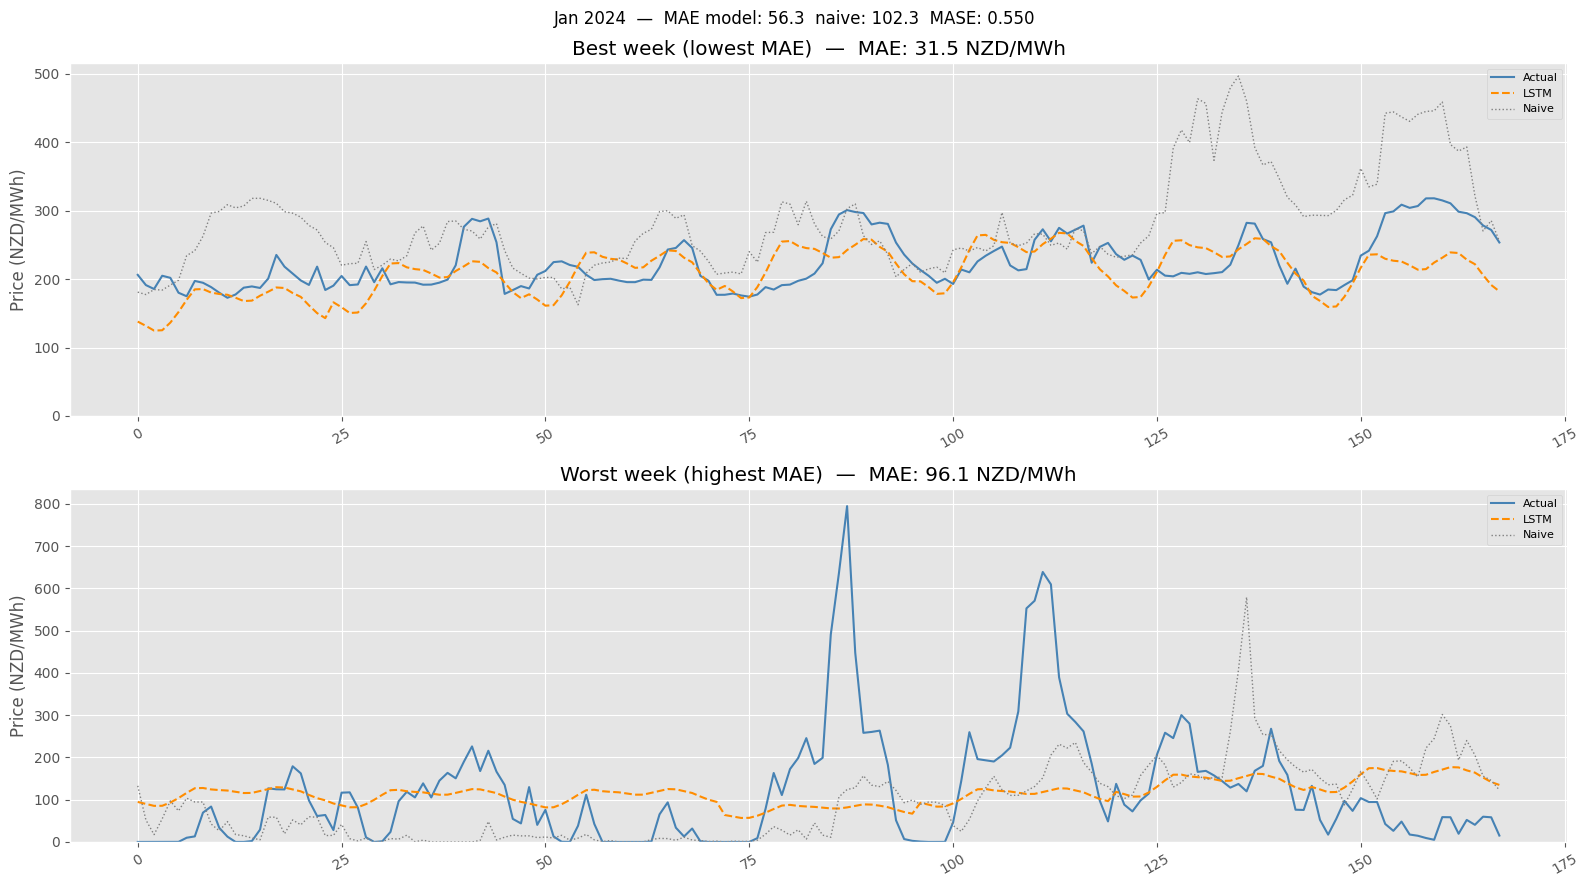

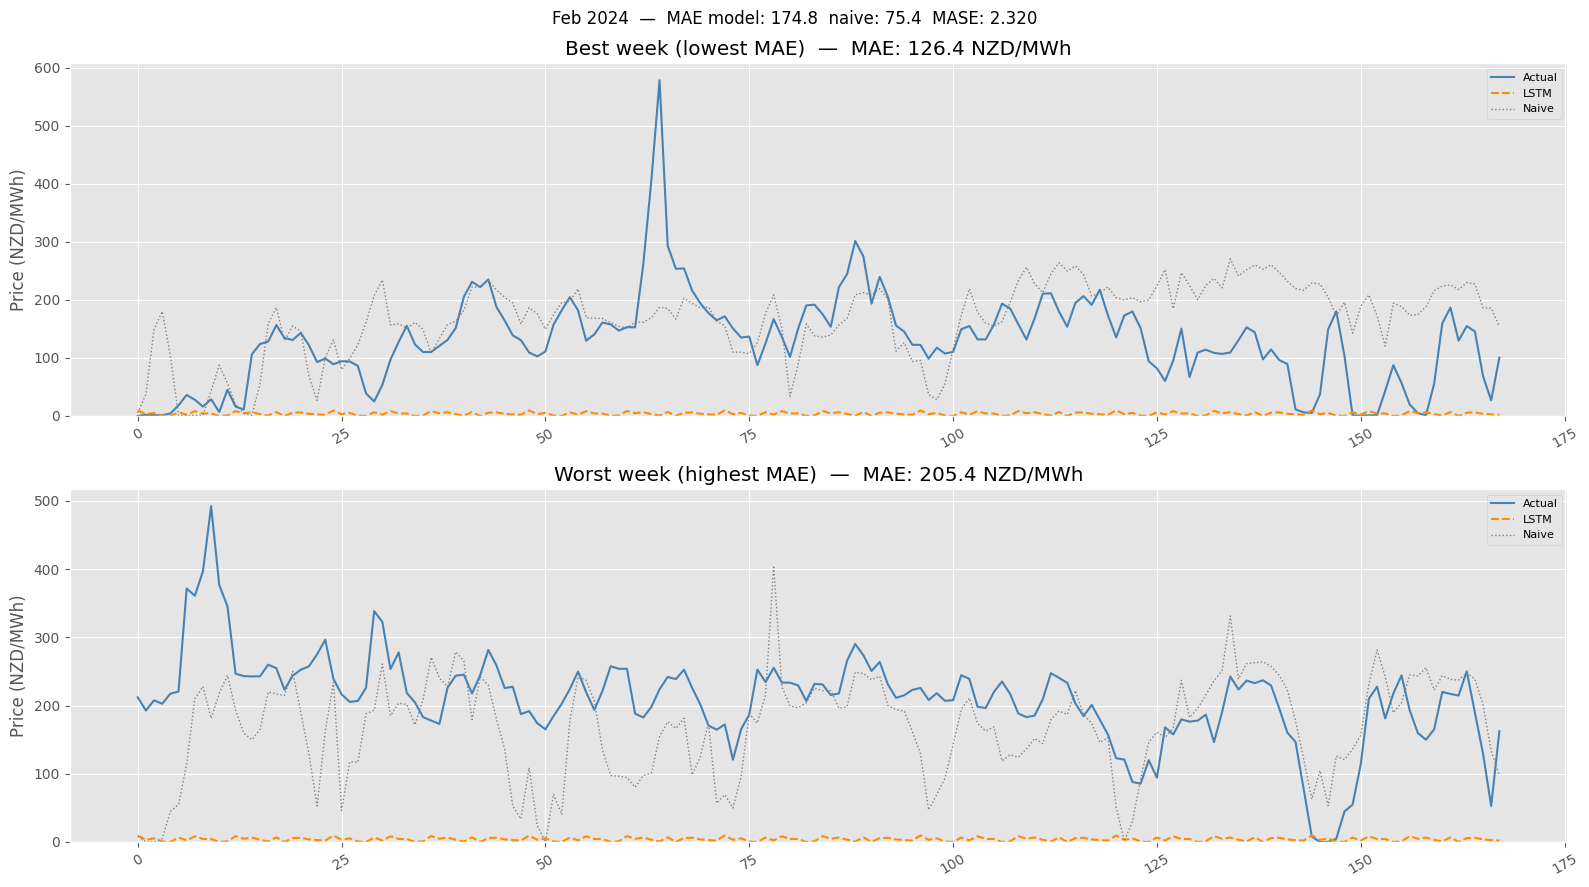

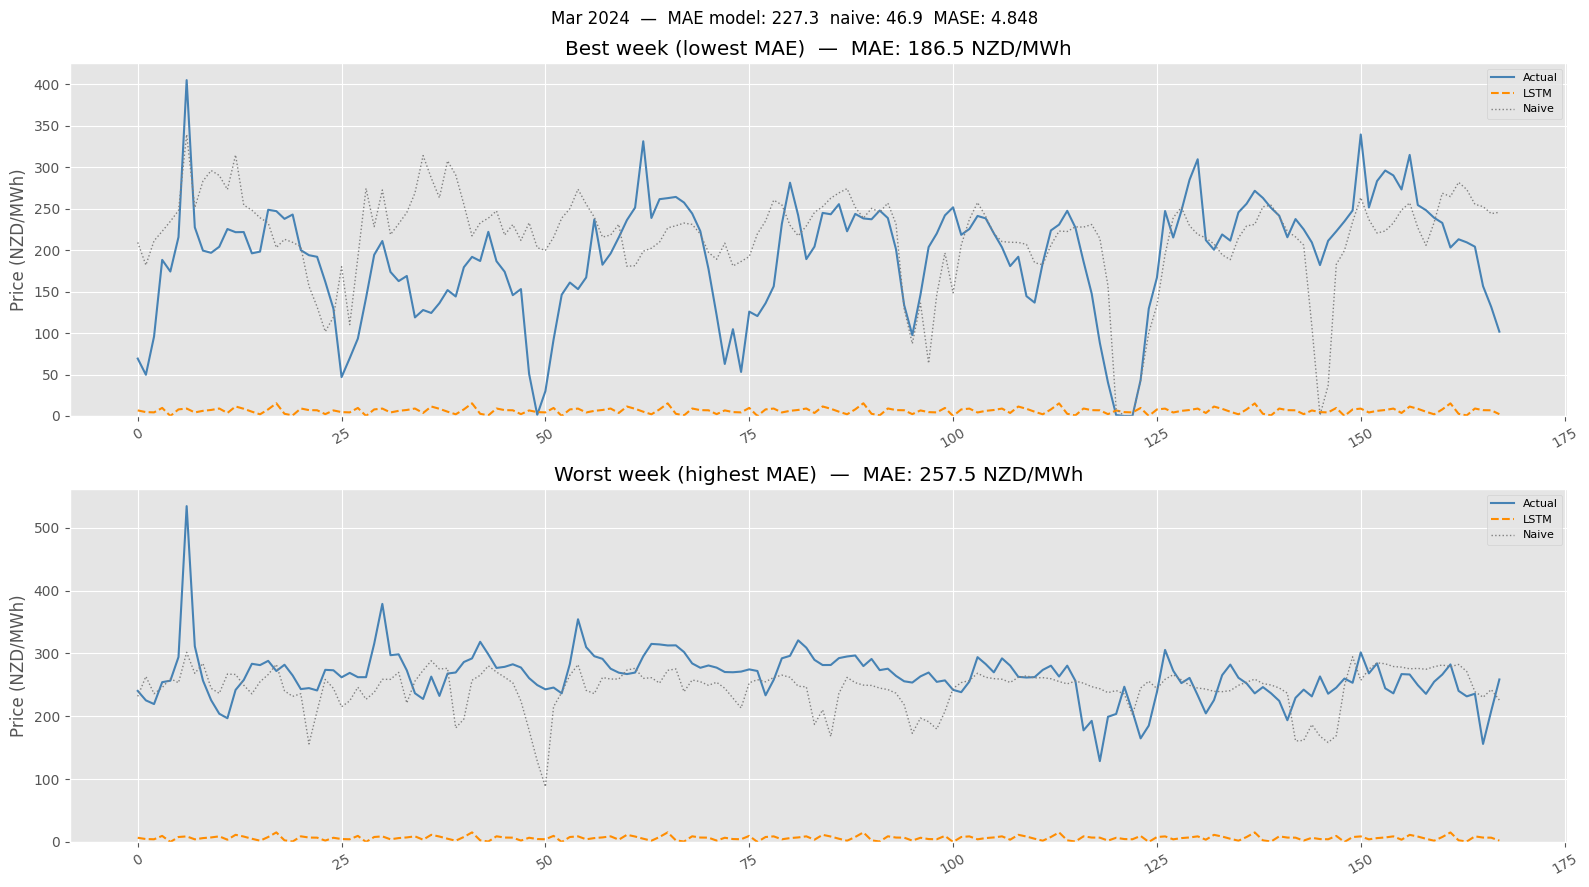

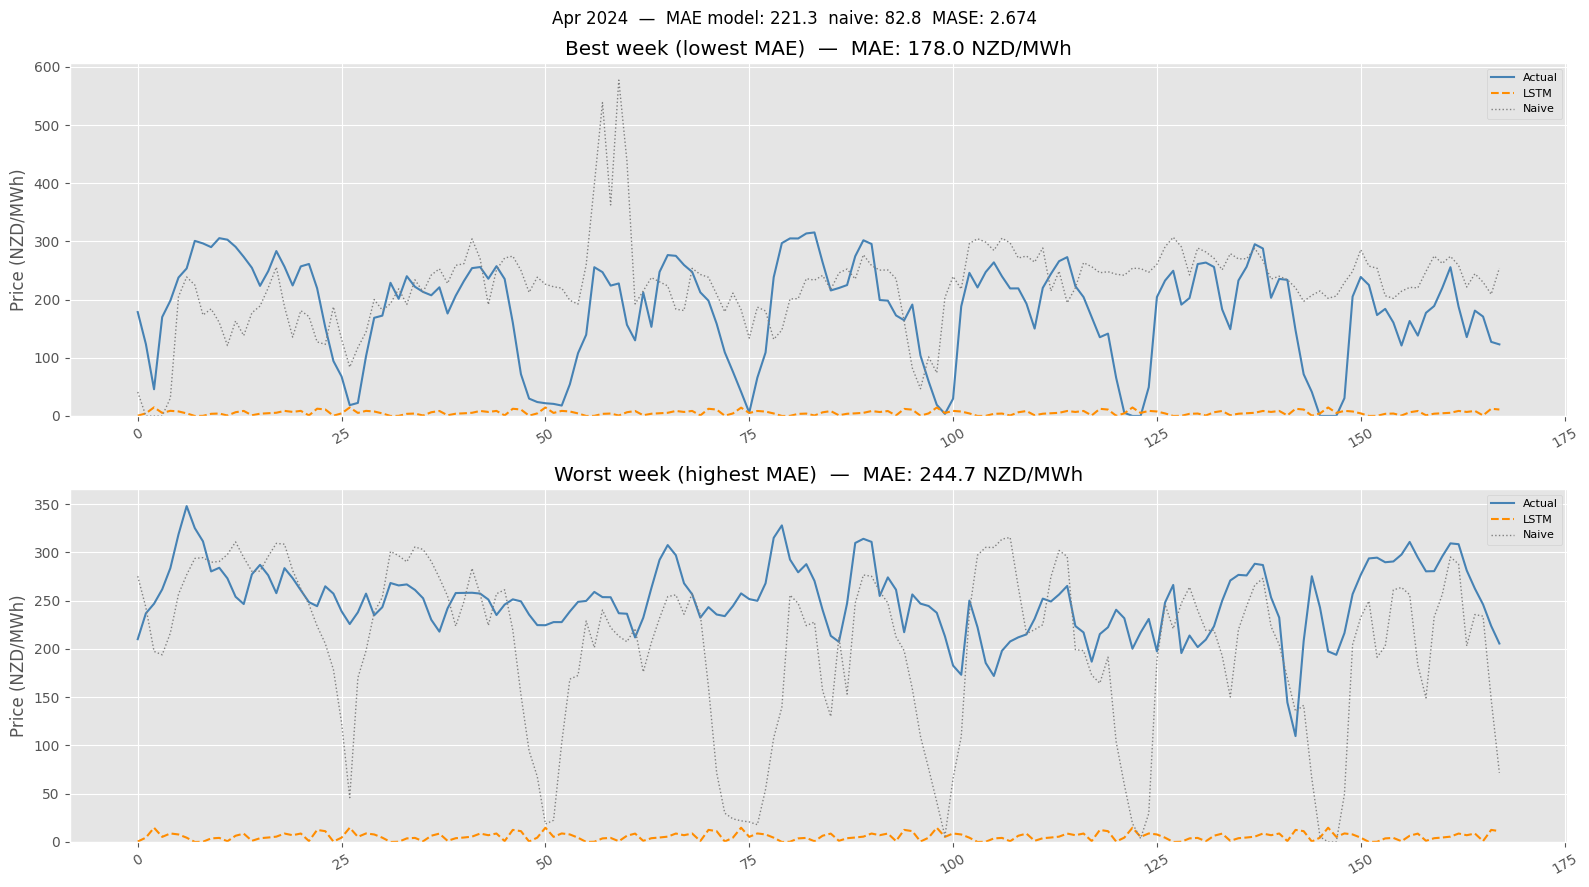

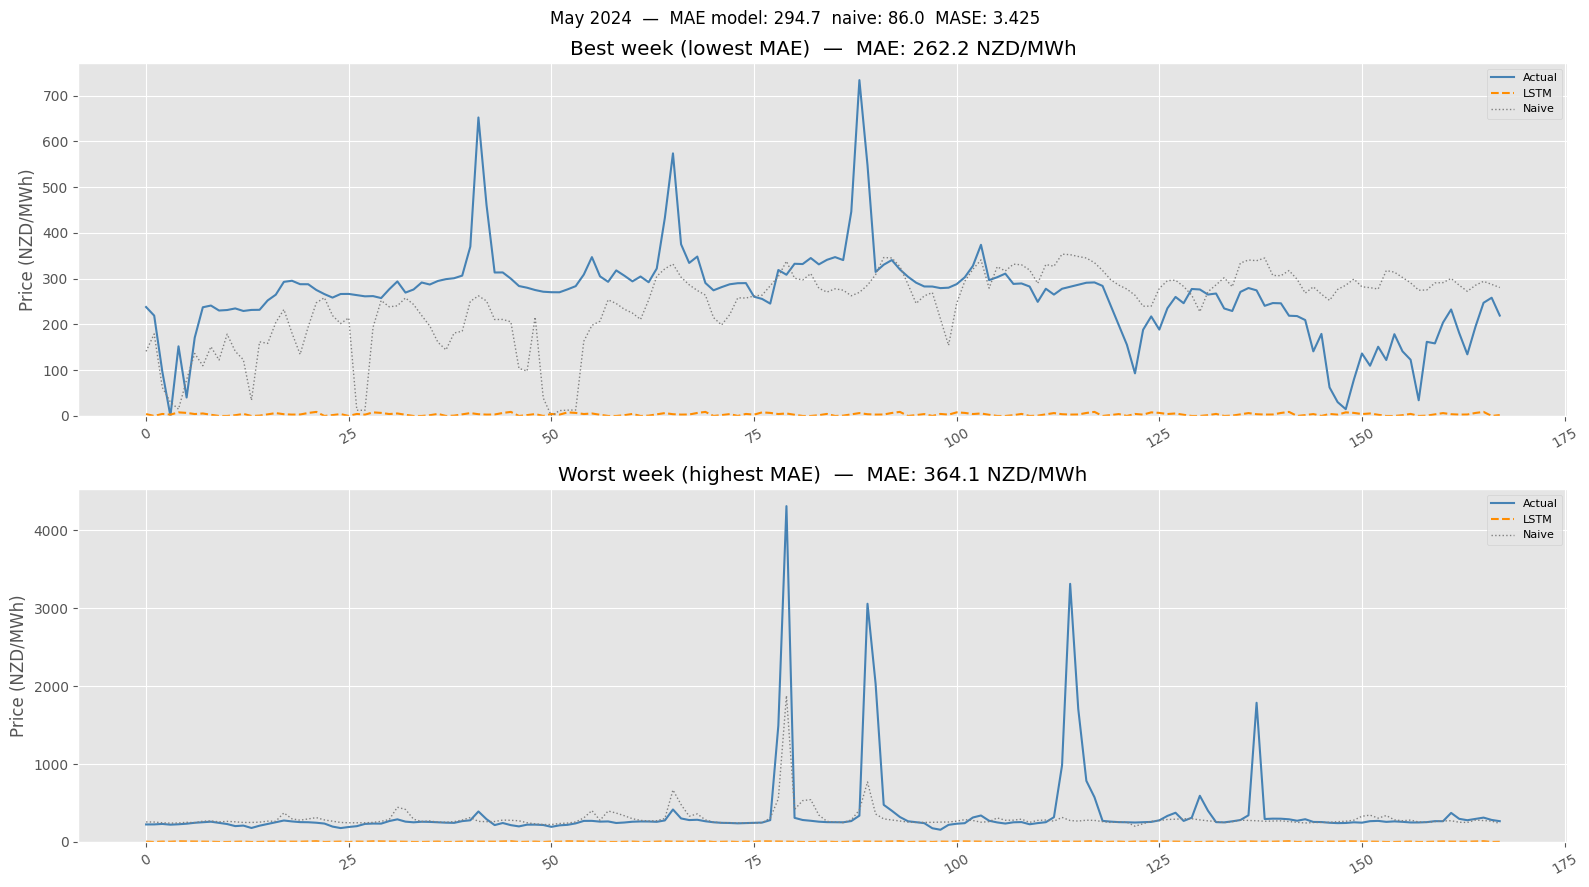

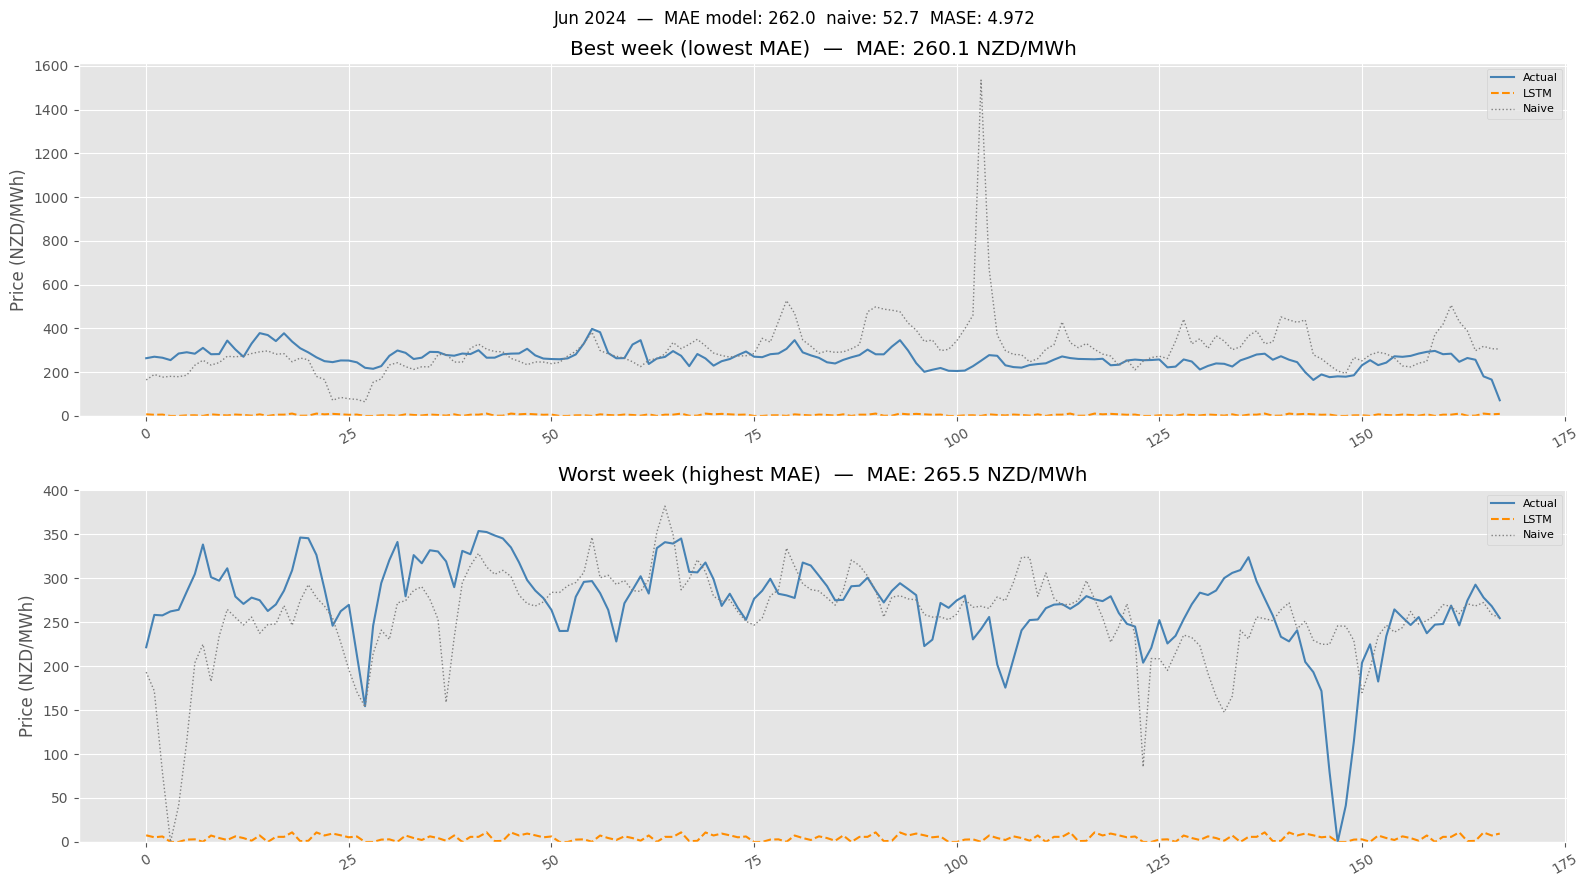

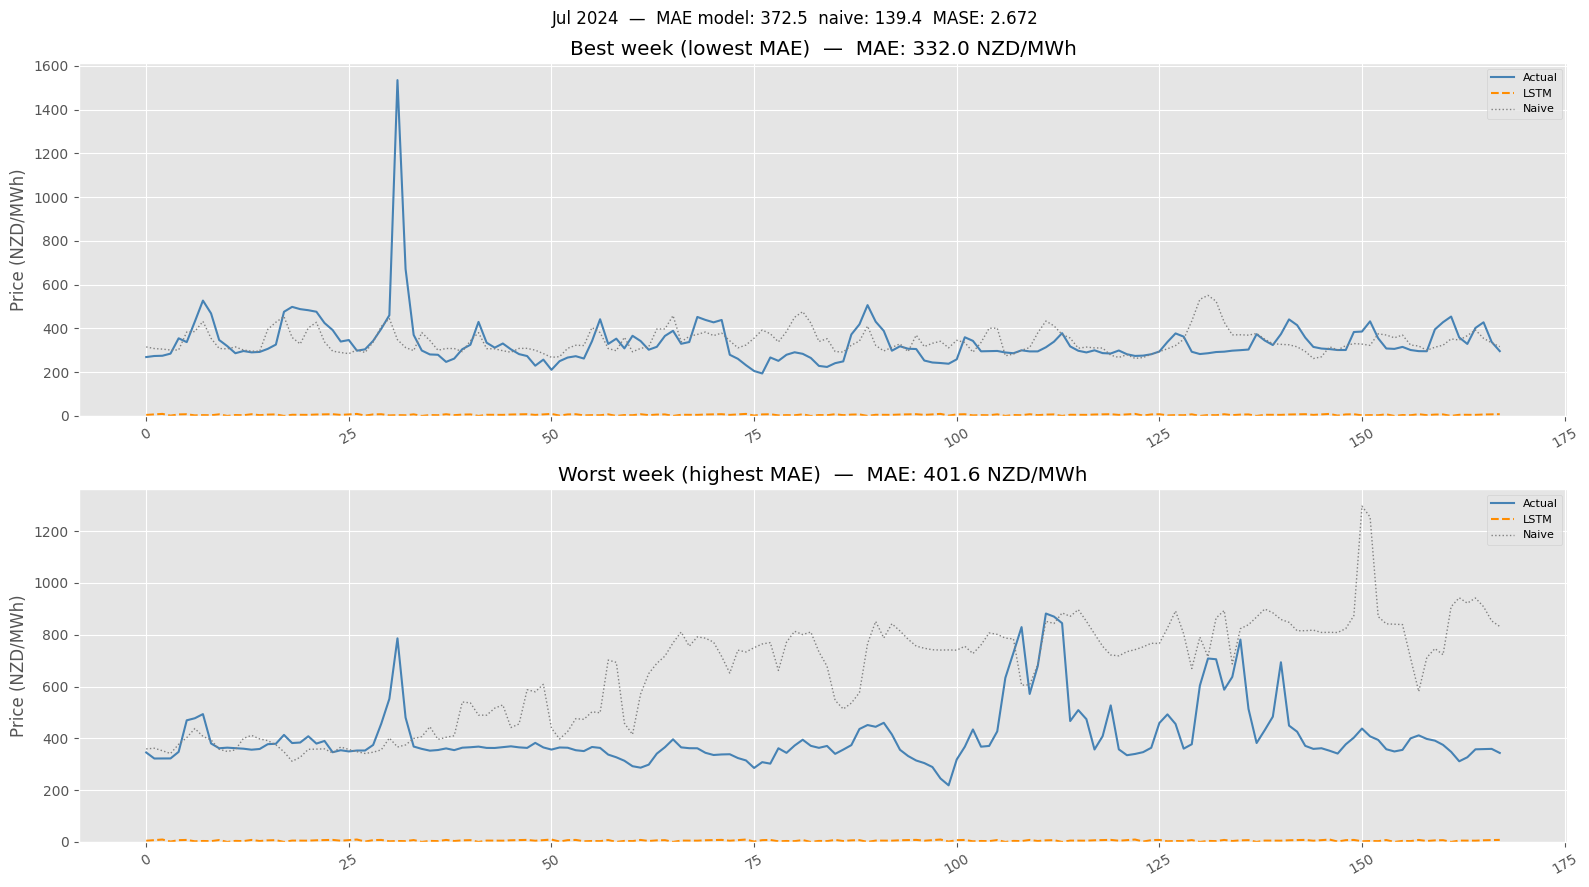

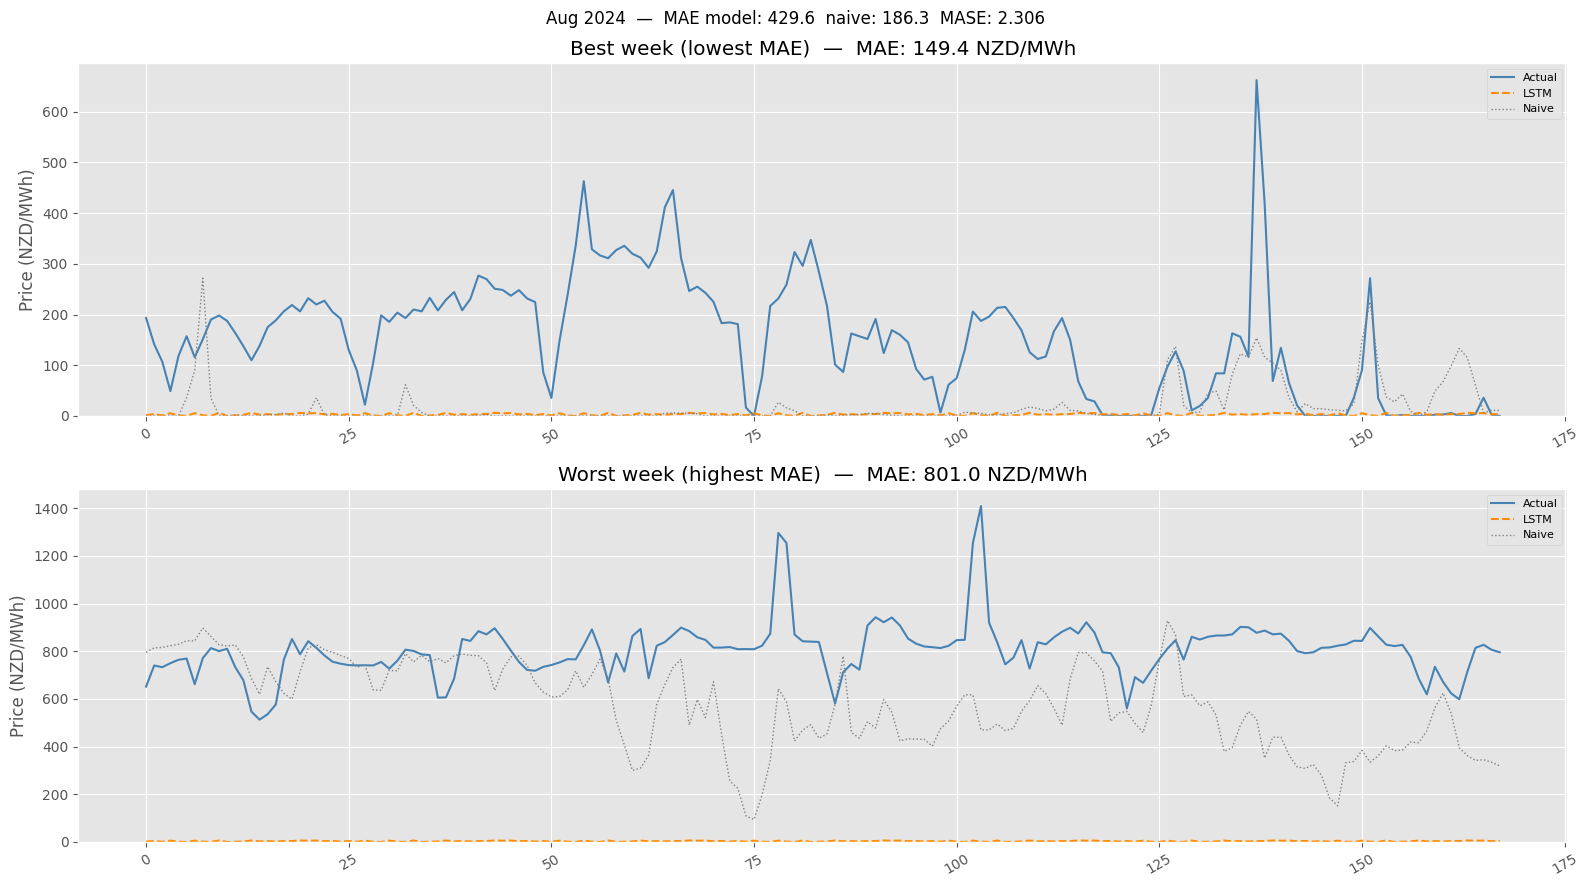

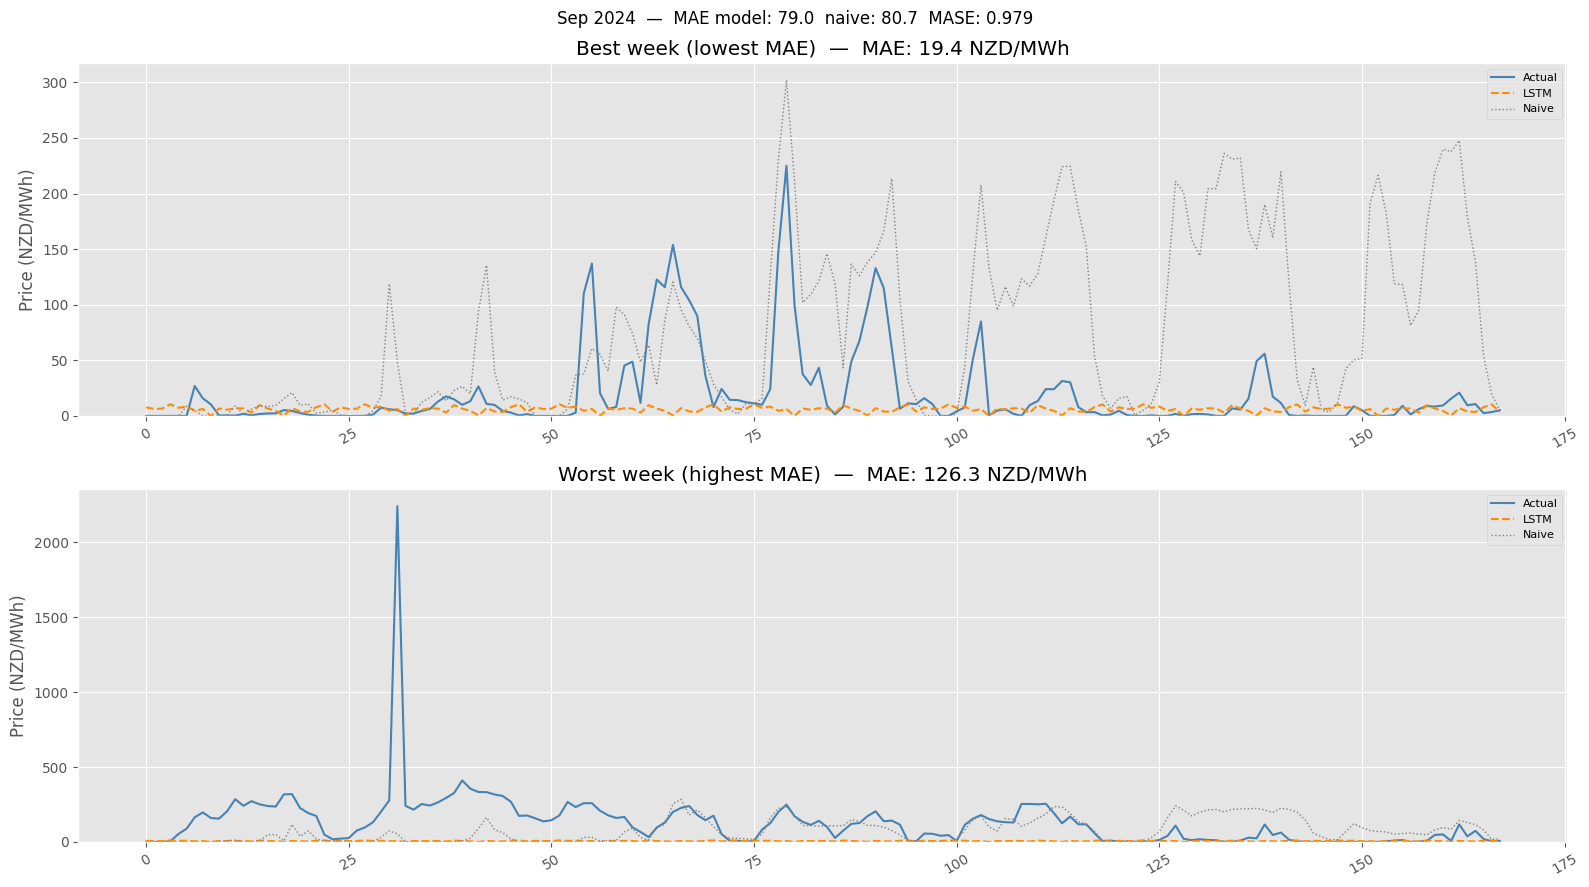

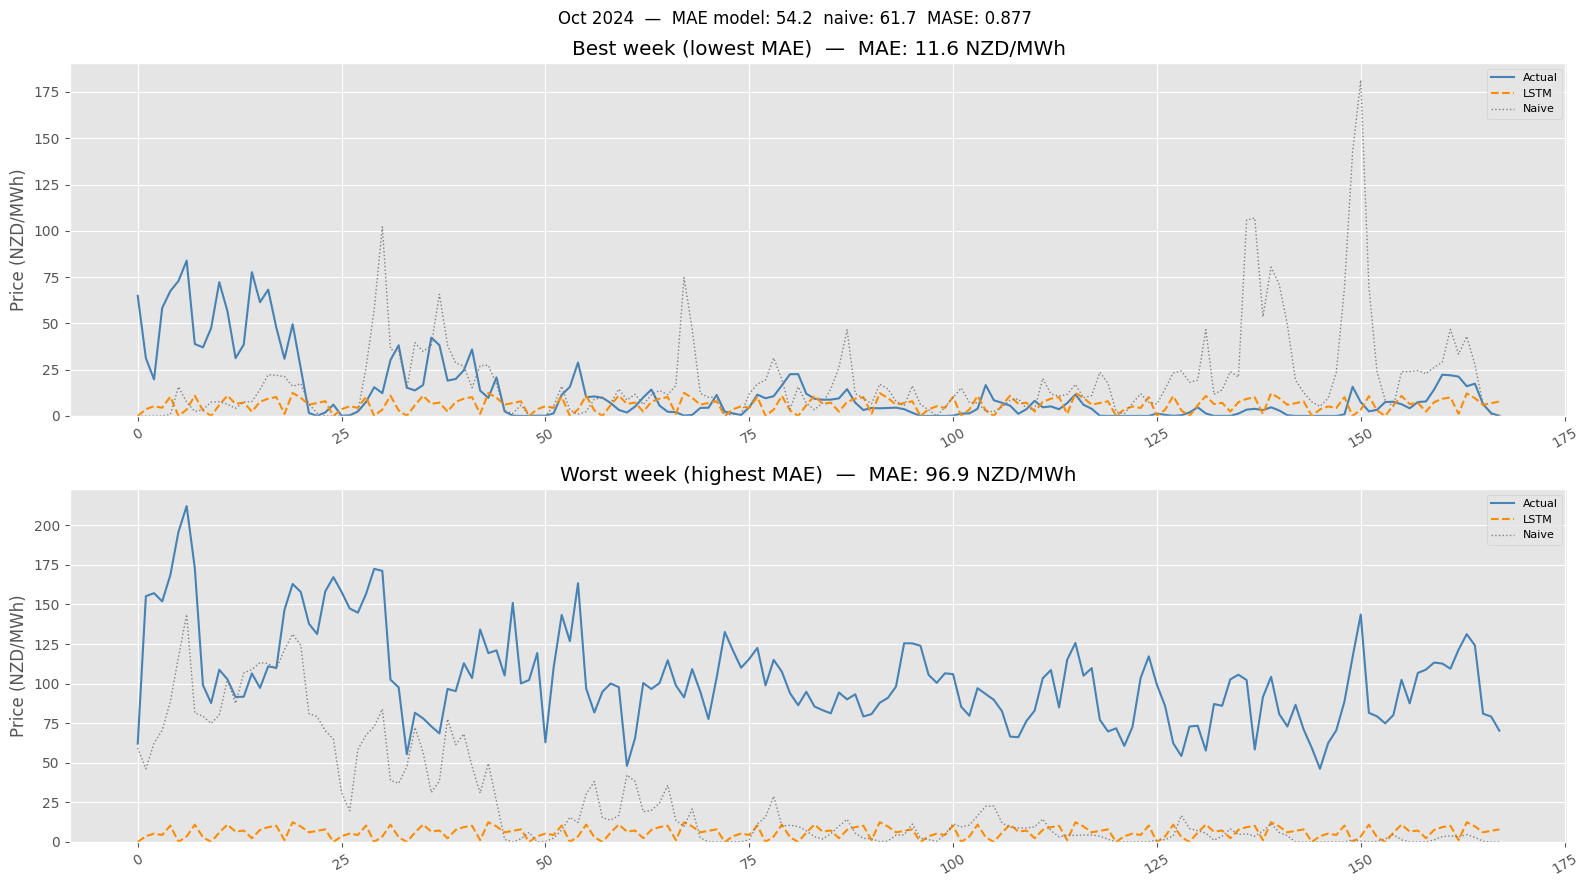

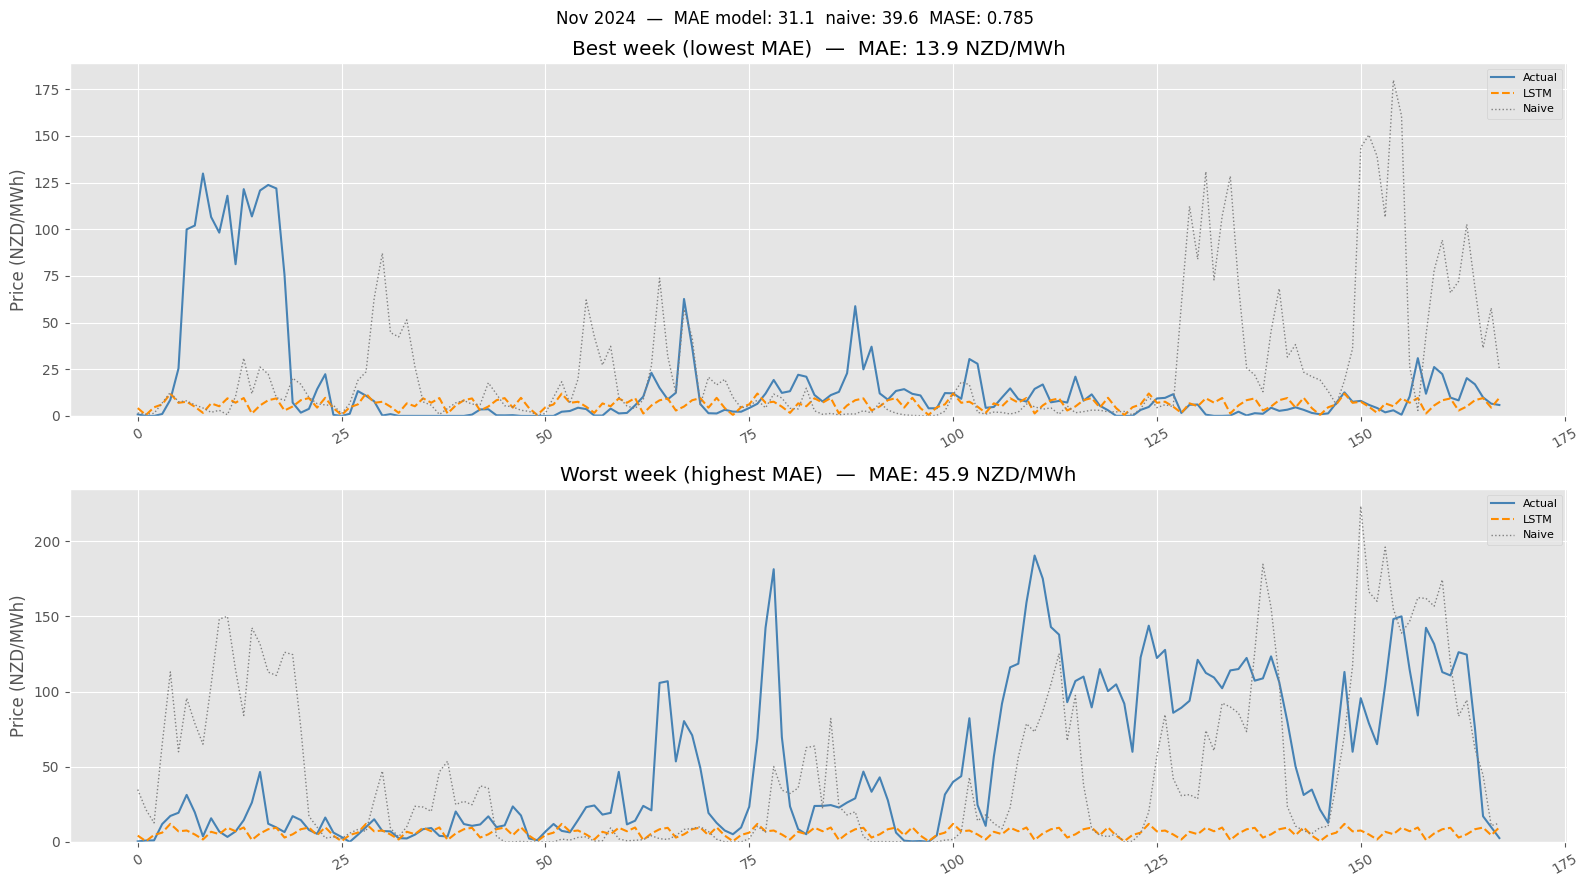

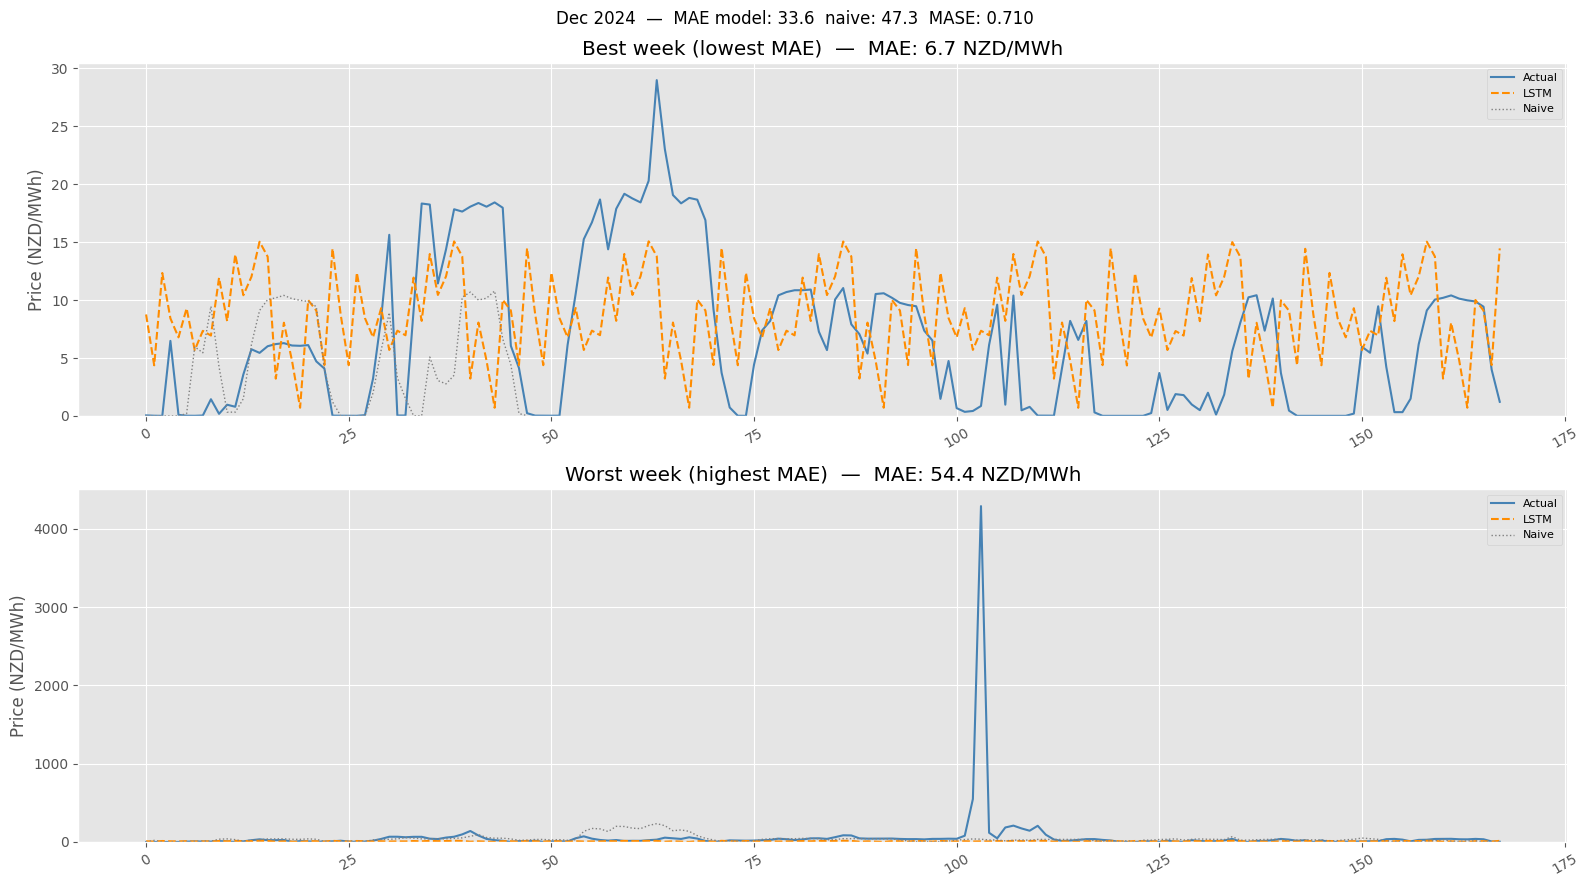

In [20]:
def find_best_worst_weeks(y_actual, y_model, week_size=168):
    n_weeks = len(y_actual) // week_size
    if n_weeks == 0:
        return (mean_absolute_error(y_actual, y_model), 0, len(y_actual)), \
               (mean_absolute_error(y_actual, y_model), 0, len(y_actual))
    week_maes = []
    for w in range(n_weeks):
        s, e = w * week_size, (w + 1) * week_size
        week_maes.append((mean_absolute_error(y_actual[s:e], y_model[s:e]), s, e))
    return min(week_maes, key=lambda x: x[0]), max(week_maes, key=lambda x: x[0])


for r in fold_results:
    best, worst = find_best_worst_weeks(r['y_actual'], r['y_model'])

    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(
        f"{r['month']}  —  MAE model: {r['mae_model']:.1f}  "
        f"naive: {r['mae_naive']:.1f}  MASE: {r['mase']:.3f}",
        fontsize=12
    )

    for ax, (mae, s, e), label in zip(
        axes,
        [best, worst],
        ['Best week (lowest MAE)', 'Worst week (highest MAE)']
    ):
        act = r['y_actual'][s:e]
        mod = r['y_model'][s:e]
        nav = r['y_naive'][s:e]

        ax.plot(act, label='Actual',  color='steelblue',  linewidth=1.5)
        ax.plot(mod, label='LSTM',    color='darkorange', linewidth=1.5, linestyle='--')
        if not np.isnan(nav).all():
            ax.plot(nav, label='Naive', color='gray',      linewidth=1.0, linestyle=':')
        ax.set_title(f"{label}  —  MAE: {mae:.1f} NZD/MWh")
        ax.set_ylabel('Price (NZD/MWh)')
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8, loc='upper right')
        ax.tick_params(axis='x', labelrotation=30)

    plt.tight_layout()
    plt.show()

## Final Model — trained on 80% with best params

In [21]:
final_scaler  = StandardScaler()
X_tr_final_sc = final_scaler.fit_transform(X_train_df.values)
X_te_final_sc = final_scaler.transform(X_test_df.values)

X_tr_fin_seq, y_tr_fin_seq = build_sequences(
    X_tr_final_sc, y_train_s.values,
    INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=True
)

lookback_X_fin = X_tr_final_sc[-INPUT_LENGTH:]
lookback_y_fin = y_train_s.values[-INPUT_LENGTH:]
X_te_fin_full  = np.concatenate([lookback_X_fin, X_te_final_sc])
y_te_fin_full  = np.concatenate([lookback_y_fin, y_test_s.values])
X_te_fin_seq, y_te_fin_seq = build_sequences(
    X_te_fin_full, y_te_fin_full,
    INPUT_LENGTH, OUTPUT_LENGTH, HORIZON, STRIDE, shuffle=False
)

es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

final_model = build_model(n_features, BEST_PARAMS)
final_model.fit(
    X_tr_fin_seq, y_tr_fin_seq,
    validation_split=0.15,
    shuffle=False,
    batch_size=BEST_PARAMS['batch_size'],
    epochs=150,
    callbacks=[es_final],
    verbose=1,
)

y_pred_final = np.clip(final_model.predict(X_te_fin_seq, verbose=0).flatten(), 0, None)
y_true_final = y_te_fin_seq.flatten()

mae_f  = mean_absolute_error(y_true_final, y_pred_final)
rmse_f = np.sqrt(mean_squared_error(y_true_final, y_pred_final))

print('Final model — best params from random search')
print(f'  MAE  : {mae_f:.4f}')
print(f'  RMSE : {rmse_f:.4f}')
print(f'\nBest params used:')
for k, v in sorted(BEST_PARAMS.items()):
    print(f'  {k:<18}: {v}')

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - loss: 104.5375 - mae: 105.0354 - val_loss: 101.1663 - val_mae: 101.6653
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - loss: 98.9998 - mae: 99.4990 - val_loss: 92.7880 - val_mae: 93.2873
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - loss: 88.1797 - mae: 88.6790 - val_loss: 79.5893 - val_mae: 80.0884
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - loss: 73.8070 - mae: 74.3056 - val_loss: 64.0925 - val_mae: 64.5905
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - loss: 60.7507 - mae: 61.2479 - val_loss: 53.6851 - val_mae: 54.1822
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 55.1106 - mae: 55.6074 - val_loss: 50.2106 - val_mae: 50.7067
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - loss: 53.8901 - mae: 54.3873 - val_loss: 49.3725 - val_mae: 49.8687
Epoch 8/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - loss: 52.9508 - mae: 53.4480 - val_loss: 49.9722 - val_mae: 50.4688
Epoch 9/150
4

## Save Final Model

In [22]:
import os
from datetime import datetime

date_str   = datetime.today().strftime('%Y%m%d')
window_str = f"{DATE_START.replace('-','') if DATE_START else 'full'}_{DATE_END.replace('-','') if DATE_END else 'full'}"
params_str = (f"L1-{BEST_PARAMS['lstm1_units']}"
              f"_L2-{BEST_PARAMS['lstm2_units']}"
              f"_do-{BEST_PARAMS['dropout']}"
              f"_lr-{BEST_PARAMS['learning_rate']}"
              f"_bs-{BEST_PARAMS['batch_size']}")
model_name = f"LSTM_OTA2201_ogdata_{date_str}_{window_str}_in{INPUT_LENGTH}_{params_str}_MAE{mae_f:.1f}.keras"

os.makedirs('saved_models', exist_ok=True)
save_path = os.path.join('saved_models', model_name)
final_model.save(save_path)

print(f"Model saved to: {save_path}")

Model saved to: saved_models/LSTM_OTA2201_ogdata_20260603_full_full_in168_L1-64_L2-64_do-0.2_lr-0.001_bs-64_MAE90.4.keras
